## Pipeline tổng quan
---

1. Import thư viện
2. Load dữ liệu
3. Khám phá dữ liệu
4. Làm sạch dữ liệu
5. Tạo feature và biến đổi feature
6. Xây dựng và so sánh mô hình
7. Đánh giá mô hình
8. Chia dữ liệu train/test chuẩn
9. Lưu model và suy luận (trước tuning)
10. Chia dữ liệu cho luồng đánh giá bổ sung
11. Bảng so sánh metric Train/Test
12. Tinh chỉnh siêu tham số
13. Train Random Forest cho luồng đánh giá bổ sung

## 1. Import thư viện
---

In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
TARGET_COL = 'Diabetes'

### Nhận xét output

- Đã import đầy đủ thư viện cho preprocessing, Random Forest, tuning và đánh giá.
- Khai báo RANDOM_STATE và TARGET_COL ngay từ đầu để đảm bảo tái lập.

## 2. Load dữ liệu
---

In [2]:
candidate_paths = [
    Path('Data_diabetes.csv'),
    Path('DATN_1') / 'Data_diabetes.csv',
    Path.cwd() / 'Data_diabetes.csv',
    Path.cwd() / 'DATN_1' / 'Data_diabetes.csv',
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Không tìm thấy Data_diabetes.csv trong thư mục hiện tại hoặc DATN_1')

BASE_DIR = data_path.resolve().parent
ARTIFACT_DIR = BASE_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(data_path, low_memory=False, encoding='latin-1')
print('Data path:', data_path.resolve())
print('Base dir:', BASE_DIR)
print('Shape:', data.shape)
data.head()

Data path: C:\Users\BSS GROUP\DATN_1\Data_diabetes.csv
Base dir: C:\Users\BSS GROUP\DATN_1
Shape: (12725, 75)


,V1,Tinh/Thanhpho,Quan/huyen,Xa/phuong,Ngay phong van,Ho ten,id,Dia chi,Gioi,Nam sinh,...,WHR_total,glucose,prediabetes2,std_wgt3,tccv,glucose2,fpg,dia,predia,fpgva
0,1785,32,1,4,40717.0,DANG THI THU HA,34.0,"TO 1, THACH THANG",2,1950,...,1,1,1,0.119252,0,1,1,0,1,0
1,1565,32,1,1,40733.0,LE THI THANH HUYEN,64.0,"TO 24, THANH BINH",2,1944,...,1,2,0,0.095826,0,2,2,1,0,0
2,460,32,1,3,40726.0,HA THUC HAI,210.0,"TO 36, BINH HIEN",1,1954,...,1,1,1,0.183041,0,1,1,0,1,0
3,1990,32,1,4,40721.0,HO THI GIAO,241.0,"TO 30, THACH THANG",2,1942,...,1,1,1,0.095826,0,1,1,0,1,0
4,978,32,2,3,40731.0,NGUYEN VAN VIEN,228.0,"TO 35, HOA KHE",1,1965,...,0,1,1,0.329838,0,1,1,0,1,0


### Nhận xét output

- Dữ liệu đã được đọc thành công.
- Kích thước bộ dữ liệu được in ra để xác nhận số dòng và số cột.

## 3. Khám phá dữ liệu
---

### Quan sát và khám phá tập dữ liệu

In [3]:
YEAR_COLLECTED = 2022

if 'Nam sinh' in data.columns:
    data['Tuoi'] = YEAR_COLLECTED - pd.to_numeric(data['Nam sinh'], errors='coerce')
    data = data.drop(columns=['Nam sinh'])

print('Đã tạo cột Tuổi và loại bỏ Năm sinh (nếu có).')
print('Shape hiện tại:', data.shape)
data.head()

Đã tạo cột Tuổi và loại bỏ Năm sinh (nếu có).
Shape hiện tại: (12725, 75)


,V1,Tinh/Thanhpho,Quan/huyen,Xa/phuong,Ngay phong van,Ho ten,id,Dia chi,Gioi,Dan toc,...,glucose,prediabetes2,std_wgt3,tccv,glucose2,fpg,dia,predia,fpgva,Tuoi
0,1785,32,1,4,40717.0,DANG THI THU HA,34.0,"TO 1, THACH THANG",2,1,...,1,1,0.119252,0,1,1,0,1,0,72
1,1565,32,1,1,40733.0,LE THI THANH HUYEN,64.0,"TO 24, THANH BINH",2,1,...,2,0,0.095826,0,2,2,1,0,0,78
2,460,32,1,3,40726.0,HA THUC HAI,210.0,"TO 36, BINH HIEN",1,1,...,1,1,0.183041,0,1,1,0,1,0,68
3,1990,32,1,4,40721.0,HO THI GIAO,241.0,"TO 30, THACH THANG",2,1,...,1,1,0.095826,0,1,1,0,1,0,80
4,978,32,2,3,40731.0,NGUYEN VAN VIEN,228.0,"TO 35, HOA KHE",1,1,...,1,1,0.329838,0,1,1,0,1,0,57


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12725 entries, 0 to 12724
Data columns (total 75 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   V1                                      12725 non-null  int64  
 1   Tinh/Thanhpho                           12725 non-null  int64  
 2   Quan/huyen                              12725 non-null  int64  
 3   Xa/phuong                               12725 non-null  int64  
 4   Ngay phong van                          12231 non-null  float64
 5   Ho ten                                  12725 non-null  str    
 6   id                                      12723 non-null  float64
 7   Dia chi                                 12724 non-null  str    
 8   Gioi                                    12725 non-null  int64  
 9   Dan toc                                 12725 non-null  int64  
 10  Tinh chat cong viec                     12725 non-null  int64  
 11  

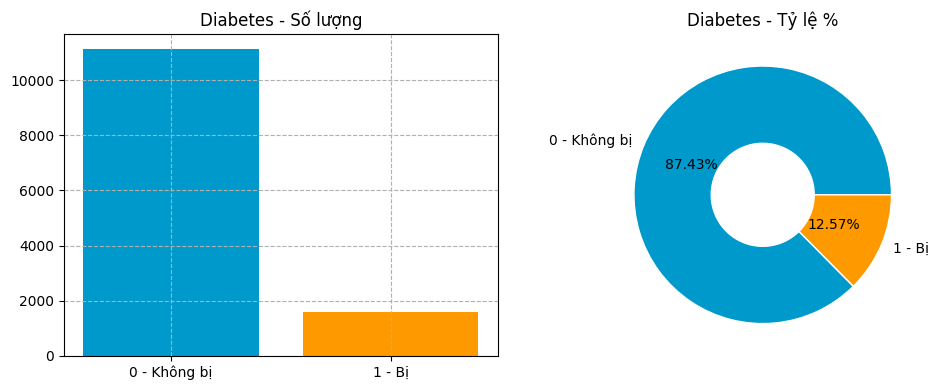

In [5]:
kq_diabetes = data[TARGET_COL].value_counts()
lb = ['0 - Không bị', '1 - Bị']

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(lb, kq_diabetes.values, color=['#0099CC', '#FF9900'])
plt.grid(ls='--')
plt.title('Diabetes - Số lượng')

plt.subplot(1, 2, 2)
plt.pie(
    kq_diabetes.values,
    labels=lb,
    colors=['#0099CC', '#FF9900'],
    autopct='%.2f%%',
    wedgeprops=dict(width=0.6, edgecolor='w')
)
plt.title('Diabetes - Tỷ lệ %')
plt.tight_layout()
plt.show()

### Nhận xét output

- Dữ liệu mất cân bằng lớp, cần ưu tiên theo dõi Recall và F1 bên cạnh Accuracy.
- Đây là cơ sở để cân nhắc class_weight trong Random Forest.

## 4. Làm sạch dữ liệu
---

### Xử lý dữ liệu thiếu, trùng lặp, kiểu dữ liệu và leakage

In [6]:
drop_cols = [
    'Glucose_class', 'Pre_diabete', 'predia',
    'glucose2', 'fpgva', 'fpg', 'glucose',
    'xet_nghiem_duong_mau_luc_doi', 'xet_nghiem_duong_mau_sau_2h',
    'WHR_male', 'WHR_female', 'WHR_male2', 'WHR_female2', 'WHR_total',
    'obesity', 'khuvuc2', 'cvd',
    'Nam chuan doan tang huyet ap',
    'std_wgt1', 'std_wgt3',
    'Ho ten', 'Dia chi', 'Ngay phong van', 'Tinh/Thanhpho', 'Quan/huyen', 'Xa/phuong',
    'V1', 'id',
    'Diabetes_binary', 'dia', 'prediabetes2',
]

leakage_keywords = ['diab', 'predia', 'pre_diab', 'fpg', 'glucose', 'xet_nghiem_duong']
keyword_drop_cols = [
    c for c in data.columns
    if c != TARGET_COL and any(k in c.lower() for k in leakage_keywords)
]

all_drop_candidates = sorted(set(drop_cols + keyword_drop_cols))
existing_drop_cols = [c for c in all_drop_candidates if c in data.columns]
data = data.drop(columns=existing_drop_cols)

print('Số cột đã xóa:', len(existing_drop_cols))
print('Shape sau khi xóa cột:', data.shape)
print('Các giá trị trùng lặp:', data.duplicated().sum())

Số cột đã xóa: 30
Shape sau khi xóa cột: (12725, 45)
Các giá trị trùng lặp: 0


In [7]:
before = len(data)
data = data[~data[TARGET_COL].isna()].copy()
data[TARGET_COL] = pd.to_numeric(data[TARGET_COL], errors='coerce').astype(int)

for c in data.columns:
    if c == TARGET_COL:
        continue
    if data[c].dtype != 'O':
        data[c] = pd.to_numeric(data[c], errors='coerce')

after = len(data)
print('Rows trước/sau clean target:', before, after)
print('Tổng missing hiện tại (xử lý trong pipeline):', int(data.isna().sum().sum()))

Rows trước/sau clean target: 12725 12725
Tổng missing hiện tại (xử lý trong pipeline): 81270


### Nhận xét output

- Đã loại bỏ nhóm cột có nguy cơ leakage nghiệp vụ.
- Missing values không điền toàn bộ ở mức dataset, sẽ được xử lý trong pipeline sau khi split.

## 5. Tạo feature và biến đổi feature
---

Mục tiêu: tạo các feature cộng hưởng có ý nghĩa để nâng cao khả năng dự đoán.

In [8]:
fe_data = data.copy()

for c in ['Tuoi', 'BMI', 'WHR', 'HATT_mean', 'HATTr_mean']:
    if c in fe_data.columns:
        fe_data[c] = pd.to_numeric(fe_data[c], errors='coerce')

if 'HATT_mean' in fe_data.columns and 'HATTr_mean' in fe_data.columns:
    fe_data['PulsePressure'] = fe_data['HATT_mean'] - fe_data['HATTr_mean']
    fe_data['MAP'] = (2 * fe_data['HATTr_mean'] + fe_data['HATT_mean']) / 3

def add_interaction(df, new_col, c1, c2):
    if c1 in df.columns and c2 in df.columns:
        df[new_col] = df[c1] * df[c2]

add_interaction(fe_data, 'Age_BMI', 'Tuoi', 'BMI')
add_interaction(fe_data, 'Age_WHR', 'Tuoi', 'WHR')

print('Số cột sau feature engineering:', fe_data.shape[1])

Số cột sau feature engineering: 49


## 6. Xây dựng và so sánh mô hình
---

In [9]:
base_df = data.copy()
valid_idx = base_df[~base_df[TARGET_COL].isna()].index
base_df = base_df.loc[valid_idx].copy()
fe_df = fe_data.loc[valid_idx].copy()

y = base_df[TARGET_COL].astype(int)
X_base = base_df.drop(columns=[TARGET_COL])
X_fe = fe_df.drop(columns=[TARGET_COL])

Xb_trainval, Xb_test, y_trainval, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

Xb_train, Xb_val, y_train, y_val = train_test_split(
    Xb_trainval, y_trainval, test_size=0.25, random_state=RANDOM_STATE, stratify=y_trainval
)

Xf_train = X_fe.loc[Xb_train.index]
Xf_val = X_fe.loc[Xb_val.index]
Xf_test = X_fe.loc[Xb_test.index]

print('Đã chuẩn bị xong dữ liệu cho baseline và feature-engineered (train/val/test)')
print(f'- Train: {Xb_train.shape}, Validation: {Xb_val.shape}, Test: {Xb_test.shape}')

Đã chuẩn bị xong dữ liệu cho baseline và feature-engineered (train/val/test)
- Train: (7635, 44), Validation: (2545, 44), Test: (2545, 44)


In [10]:
def build_rf_pipeline(X_train):
    num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
    cat_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()

    transformers = []
    if num_cols:
        transformers.append((
            'num',
            Pipeline([('imputer', SimpleImputer(strategy='median'))]),
            num_cols,
        ))
    if cat_cols:
        transformers.append((
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]),
            cat_cols,
        ))

    return Pipeline([
        ('prep', ColumnTransformer(transformers=transformers)),
        ('model', RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])


def evaluate_model(pipe, X_train, X_test, y_train, y_test):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, y_prob),
    }
    return metrics, classification_report(y_test, y_pred), confusion_matrix(y_test, y_pred)

In [11]:
baseline_pipe = build_rf_pipeline(Xb_train)
fe_pipe = build_rf_pipeline(Xf_train)

baseline_metrics, baseline_report, baseline_cm = evaluate_model(
    baseline_pipe, Xb_train, Xb_val, y_train, y_val
)
fe_metrics, fe_report, fe_cm = evaluate_model(
    fe_pipe, Xf_train, Xf_val, y_train, y_val
)

baseline_train_metrics, _, _ = evaluate_model(
    build_rf_pipeline(Xb_train), Xb_train, Xb_train, y_train, y_train
)
fe_train_metrics, _, _ = evaluate_model(
    build_rf_pipeline(Xf_train), Xf_train, Xf_train, y_train, y_train
)

model_compare = pd.DataFrame([
    {
        'Model': 'Baseline',
        'F1_Train': baseline_train_metrics['F1'],
        'F1_Val': baseline_metrics['F1'],
        'F1_Gap': baseline_train_metrics['F1'] - baseline_metrics['F1'],
        'Recall_Val': baseline_metrics['Recall'],
        'Precision_Val': baseline_metrics['Precision'],
        'ROC_AUC_Val': baseline_metrics['ROC_AUC'],
    },
    {
        'Model': 'Feature_Engineered',
        'F1_Train': fe_train_metrics['F1'],
        'F1_Val': fe_metrics['F1'],
        'F1_Gap': fe_train_metrics['F1'] - fe_metrics['F1'],
        'Recall_Val': fe_metrics['Recall'],
        'Precision_Val': fe_metrics['Precision'],
        'ROC_AUC_Val': fe_metrics['ROC_AUC'],
    }
])

model_compare['SelectionScore'] = model_compare['F1_Val'] - model_compare['F1_Gap']
selected_row = model_compare.sort_values(['SelectionScore', 'F1_Val'], ascending=False).iloc[0]
selected_model_name = selected_row['Model']

if selected_model_name == 'Baseline':
    X_train_best, X_val_best, X_test_best = Xb_train, Xb_val, Xb_test
    selected_pipe = baseline_pipe
else:
    X_train_best, X_val_best, X_test_best = Xf_train, Xf_val, Xf_test
    selected_pipe = fe_pipe

print('Mô hình được chọn (quy tắc chống overfitting):', selected_model_name)
model_compare.round(4)

Mô hình được chọn (quy tắc chống overfitting): Baseline


,Model,F1_Train,F1_Val,F1_Gap,Recall_Val,Precision_Val,ROC_AUC_Val,SelectionScore
0,Baseline,1.0,0.0604,0.9396,0.0312,0.9091,0.6927,-0.8792
1,Feature_Engineered,1.0,0.0604,0.9396,0.0312,0.9091,0.6858,-0.8792


### Nhận xét output

- Kết quả so sánh cho thấy cả 2 biến thể có F1_Val giống nhau (**0.0604**) và F1_Gap rất lớn (**0.9396**), thể hiện overfitting mạnh.
- Baseline được chọn theo quy tắc chống overfitting (SelectionScore = **-0.8792**, bằng với Feature_Engineered nhưng được ưu tiên theo thứ tự).
- ROC_AUC_Val của Baseline (**0.6927**) nhỉnh hơn Feature_Engineered (**0.6858**).

## 7. Đánh giá mô hình
---

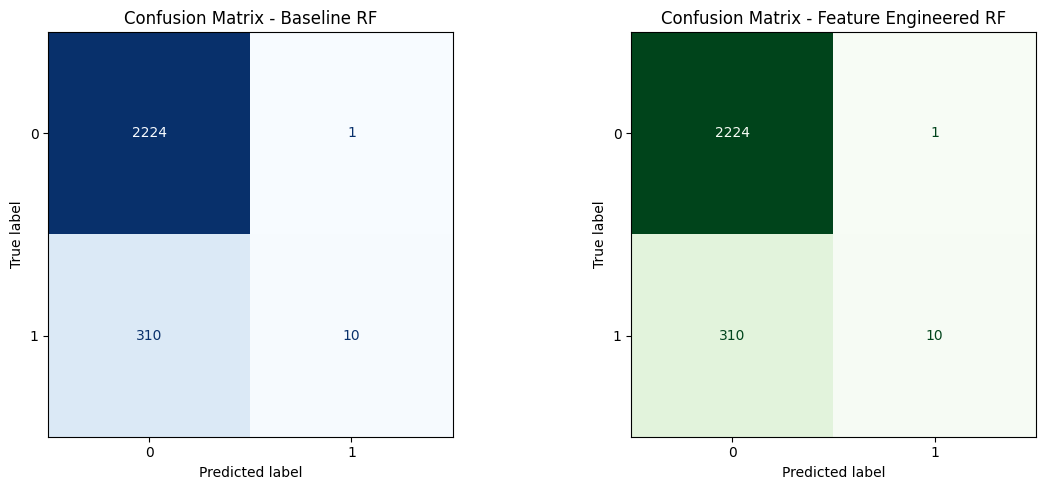

Báo cáo phân loại - Baseline RF
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      2225
           1       0.91      0.03      0.06       320

    accuracy                           0.88      2545
   macro avg       0.89      0.52      0.50      2545
weighted avg       0.88      0.88      0.82      2545


Báo cáo phân loại - Feature Engineered RF
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      2225
           1       0.91      0.03      0.06       320

    accuracy                           0.88      2545
   macro avg       0.89      0.52      0.50      2545
weighted avg       0.88      0.88      0.82      2545



In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp1 = ConfusionMatrixDisplay(confusion_matrix=baseline_cm)
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix - Baseline RF')
axes[0].grid(False)

disp2 = ConfusionMatrixDisplay(confusion_matrix=fe_cm)
disp2.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix - Feature Engineered RF')
axes[1].grid(False)

plt.tight_layout()
plt.show()

print('Báo cáo phân loại - Baseline RF')
print(baseline_report)
print('\nBáo cáo phân loại - Feature Engineered RF')
print(fe_report)

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_validate(
    selected_pipe,
    X_train_best,
    y_train,
    cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    n_jobs=-1,
)

cv_summary = pd.Series({
    'Mô_hình_được_chọn': selected_model_name,
    'CV_Accuracy_Mean': np.mean(cv_scores['test_accuracy']),
    'CV_Precision_Mean': np.mean(cv_scores['test_precision']),
    'CV_Recall_Mean': np.mean(cv_scores['test_recall']),
    'CV_F1_Mean': np.mean(cv_scores['test_f1']),
    'CV_ROC_AUC_Mean': np.mean(cv_scores['test_roc_auc']),
})

for metric in ['CV_Accuracy_Mean', 'CV_Precision_Mean', 'CV_Recall_Mean', 'CV_F1_Mean', 'CV_ROC_AUC_Mean']:
    cv_summary[metric] = round(float(cv_summary[metric]), 4)

cv_summary

Mô_hình_được_chọn    Baseline
CV_Accuracy_Mean       0.8761
CV_Precision_Mean      0.7048
CV_Recall_Mean         0.0167
CV_F1_Mean             0.0323
CV_ROC_AUC_Mean        0.7109
dtype: object

### Nhận xét output

- Trên validation, confusion matrix cho Baseline và Feature Engineered giống nhau: **TN=2224, FP=1, FN=310, TP=10**.
- Lớp dương tính có Recall rất thấp (**0.0312**) dù Precision cao (**0.9091**), nên F1 lớp bệnh còn thấp (**0.0604**).
- Cross-validation của mô hình được chọn: Accuracy **0.8761**, Precision **0.7048**, Recall **0.0167**, F1 **0.0323**, ROC-AUC **0.7109**.

## 8. Chia dữ liệu train/test chuẩn
---

In [15]:
train_df = pd.concat([
    X_train_best.assign(**{TARGET_COL: y_train.values}),
    X_val_best.assign(**{TARGET_COL: y_val.values}),
], axis=0)
test_df = X_test_best.copy()
test_df[TARGET_COL] = y_test.values

train_path = BASE_DIR / 'train_diabetes_rf.csv'
test_path = BASE_DIR / 'test_diabetes_rf.csv'
train_df.to_csv(train_path, index=False, encoding='utf-8')
test_df.to_csv(test_path, index=False, encoding='utf-8')

print('Mô hình được chọn để export:', selected_model_name)
print('Train (train+val):', train_df.shape, 'Test holdout:', test_df.shape)
print('Đã lưu file train:', train_path)
print('Đã lưu file test:', test_path)

Mô hình được chọn để export: Baseline
Train (train+val): (10180, 45) Test holdout: (2545, 45)
Đã lưu file train: C:\Users\BSS GROUP\DATN_1\train_diabetes_rf.csv
Đã lưu file test: C:\Users\BSS GROUP\DATN_1\test_diabetes_rf.csv


### Nhận xét output

- Holdout test được giữ nguyên từ bước split ban đầu, không chia lại.
- File export riêng cho Random Forest để không ảnh hưởng luồng Logistic.

## 9. Lưu model và suy luận (trước tuning)
---

In [16]:
pre_tuned_model = selected_pipe
pre_tuned_model.fit(X_train_best, y_train)

model_path = ARTIFACT_DIR / 'diabetes_rf_pipeline_pre_tuning.joblib'
meta_path = ARTIFACT_DIR / 'diabetes_rf_model_metadata_pre_tuning.joblib'

joblib.dump(pre_tuned_model, model_path)
joblib.dump(
    {
        'model_name': f'{selected_model_name}_RF_PreTuning',
        'target_col': TARGET_COL,
        'feature_list': X_train_best.columns.tolist(),
        'selected_model_by_val_f1': selected_model_name,
        'note': 'Demo inference trên validation sample',
    },
    meta_path,
)

print('Đã lưu model pre-tuning:', model_path.resolve())

X_new = X_val_best.head(5).copy()
pred = pre_tuned_model.predict(X_new)
prob = pre_tuned_model.predict_proba(X_new)[:, 1]
infer_df = X_new.copy()
infer_df['pred_label'] = pred
infer_df['pred_prob_diabetes'] = prob
infer_df.head()

Đã lưu model pre-tuning: C:\Users\BSS GROUP\DATN_1\artifacts\diabetes_rf_pipeline_pre_tuning.joblib


,Gioi,Dan toc,Tinh chat cong viec,Trinh do van hoa,Thoi gian an cach bua toi,Tien xu bi tang huyet ap,Da dieu tri tang huyet ap bao gio chua,Bang an uong va luyen tap,DT_THA_DY,DT_THA_TY,...,BMI_class,Abdominal_Obese,Hypertension_class,WHR,WHR_class,khuvuc,tccv,Tuoi,pred_label,pred_prob_diabetes
2189,2,1,3,3,10,2,NaN,NaN,NaN,NaN,...,2,1,3.0,0.958333,4,2,1,60,0,0.1525
7655,1,1,4,2,11,2,NaN,NaN,NaN,NaN,...,3,0,1.0,1.012048,4,3,2,54,0,0.1550
11561,2,1,2,3,12,2,NaN,NaN,NaN,NaN,...,2,0,NaN,NaN,2,2,0,51,0,0.0900
1811,2,1,2,5,9,1,2.0,2.0,2.0,1.0,...,3,1,1.0,0.895833,4,2,0,66,0,0.3150
2460,2,1,2,3,9,2,NaN,NaN,NaN,NaN,...,2,0,NaN,0.872093,4,2,0,79,0,0.1500


### Nhận xét output

- Đã lưu model trước tuning cho demo inference nhanh.
- Bước 12 sẽ cập nhật artifact cuối cùng sau tuning.

## 10. Chia dữ liệu cho luồng đánh giá bổ sung
---

In [17]:
df_new = fe_data.copy()
if 'Diabetes_binary' in df_new.columns:
    target_col_aux = 'Diabetes_binary'
else:
    target_col_aux = TARGET_COL

X_aux_raw = df_new.drop(columns=[target_col_aux]).select_dtypes(include=['number']).copy()
y_aux = pd.to_numeric(df_new[target_col_aux], errors='coerce').fillna(0).astype(int)

X_train_aux, X_test_aux, y_train_aux, y_test_aux = train_test_split(
    X_aux_raw, y_aux, test_size=0.3, random_state=RANDOM_STATE, stratify=y_aux
)

train_medians = X_train_aux.median(numeric_only=True)
X_train_aux = X_train_aux.fillna(train_medians)
X_test_aux = X_test_aux.fillna(train_medians)

print('X_train_aux:', X_train_aux.shape, 'X_test_aux:', X_test_aux.shape)

X_train_aux: (8907, 48) X_test_aux: (3818, 48)


### Nhận xét output

- Luồng phụ được split trước và fill missing theo thống kê train để tránh leakage.
- Luồng này dùng để đối chiếu độ ổn định, không thay thế kết luận luồng chính.

## 11. Bảng so sánh metric Train/Test
---

In [18]:
aux_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
aux_model.fit(X_train_aux, y_train_aux)

y_train_pred_aux = aux_model.predict(X_train_aux)
y_test_pred_aux = aux_model.predict(X_test_aux)

comparison_aux = pd.DataFrame({
    'Tap': ['Test', 'Train'],
    'Recall': [recall_score(y_test_aux, y_test_pred_aux), recall_score(y_train_aux, y_train_pred_aux)],
    'Precision': [precision_score(y_test_aux, y_test_pred_aux, zero_division=0), precision_score(y_train_aux, y_train_pred_aux, zero_division=0)],
    'F1 Score': [f1_score(y_test_aux, y_test_pred_aux, zero_division=0), f1_score(y_train_aux, y_train_pred_aux, zero_division=0)],
    'Accuracy': [accuracy_score(y_test_aux, y_test_pred_aux), accuracy_score(y_train_aux, y_train_pred_aux)],
})
comparison_aux.round(4)

,Tap,Recall,Precision,F1 Score,Accuracy
0,Test,0.025,0.9231,0.0487,0.8772
1,Train,1.000,1.0000,1.0000,1.0000


### Nhận xét output

- Bảng Train/Test ở luồng bổ sung cho thấy overfitting rõ: Train gần như hoàn hảo (**Accuracy/F1 = 1.0000**).
- Trên Test, mô hình chỉ đạt: Recall **0.0250**, Precision **0.9231**, F1 **0.0487**, Accuracy **0.8772**.
- Mô hình đang thiên về dự đoán lớp 0, dẫn tới bỏ sót nhiều ca lớp 1 (FN cao).

## 12. Tinh chỉnh siêu tham số
---

In [19]:
X_train_tune = X_train_best.copy()
X_val_tune = X_val_best.copy()
X_test_tune = X_test_best.copy()

pipe_tune = build_rf_pipeline(X_train_tune)

param_grid = {
    'model__n_estimators': [200, 400, 600],
    'model__max_depth': [None, 8, 12],
    'model__min_samples_split': [2, 10, 30],
    'model__min_samples_leaf': [1, 5, 10],
    'model__max_features': ['sqrt', 0.5],
    'model__class_weight': ['balanced', 'balanced_subsample'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(pipe_tune, param_grid=param_grid, scoring='f1', cv=cv, n_jobs=-1, refit=True)
grid.fit(X_train_tune, y_train)

best_tuned_pipe = grid.best_estimator_
tuned_val_metrics, tuned_val_report, tuned_val_cm = evaluate_model(
    best_tuned_pipe, X_train_tune, X_val_tune, y_train, y_val
)

X_trainval_tune = pd.concat([X_train_tune, X_val_tune], axis=0)
y_trainval_tune = pd.concat([y_train, y_val], axis=0)

final_pipe = build_rf_pipeline(X_trainval_tune)
final_pipe.set_params(**grid.best_params_)
final_test_metrics, tuned_report, tuned_cm = evaluate_model(
    final_pipe, X_trainval_tune, X_test_tune, y_trainval_tune, y_test
)

final_model_path = ARTIFACT_DIR / 'diabetes_rf_pipeline.joblib'
final_meta_path = ARTIFACT_DIR / 'diabetes_rf_model_metadata.joblib'

joblib.dump(final_pipe, final_model_path)
joblib.dump(
    {
        'model_name': f'{selected_model_name}_RF_Tuned',
        'target_col': TARGET_COL,
        'feature_list': X_trainval_tune.columns.tolist(),
        'selected_model_by_val_f1': selected_model_name,
        'best_cv_f1': float(grid.best_score_),
        'best_params': grid.best_params_,
        'validation_metrics': tuned_val_metrics,
        'test_metrics': final_test_metrics,
    },
    final_meta_path,
)

print('Mô hình được chọn:', selected_model_name)
print('Best CV F1:', round(grid.best_score_, 4))
print('Tham số tốt nhất:', grid.best_params_)
print('Metric validation:', pd.Series(tuned_val_metrics).round(4).to_dict())
print('Đã cập nhật artifact cuối cùng:', final_model_path.resolve())
pd.Series(final_test_metrics).round(4)

Mô hình được chọn: Baseline
Best CV F1: 0.3221
Tham số tốt nhất: {'model__class_weight': 'balanced_subsample', 'model__max_depth': 8, 'model__max_features': 0.5, 'model__min_samples_leaf': 5, 'model__min_samples_split': 30, 'model__n_estimators': 400}
Metric validation: {'Accuracy': 0.7363, 'Precision': 0.2408, 'Recall': 0.5094, 'F1': 0.327, 'ROC_AUC': 0.7022}
Đã cập nhật artifact cuối cùng: C:\Users\BSS GROUP\DATN_1\artifacts\diabetes_rf_pipeline.joblib


Accuracy     0.7155
Precision    0.2194
Recall       0.4938
F1           0.3038
ROC_AUC      0.6955
dtype: float64

### Nhận xét output

- GridSearchCV tìm được bộ tham số tốt nhất: class_weight=`balanced_subsample`, max_depth=`8`, max_features=`0.5`, min_samples_leaf=`5`, min_samples_split=`30`, n_estimators=`400`.
- Best CV F1 đạt **0.3221**, cải thiện đáng kể so với trước tuning.
- Validation sau tuning: Accuracy **0.7363**, Precision **0.2408**, Recall **0.5094**, F1 **0.3270**, ROC-AUC **0.7022**.
- Test holdout cuối cùng: Accuracy **0.7155**, Precision **0.2194**, Recall **0.4938**, F1 **0.3038**, ROC-AUC **0.6955**.
- Artifact cuối cùng đã lưu tại thư mục artifacts để dùng cho báo cáo và suy luận.

## 13. Train Random Forest cho luồng đánh giá bổ sung
---

In [20]:
model_aux_final = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
model_aux_final.fit(X_train_aux, y_train_aux)

y_pred_aux_final = model_aux_final.predict(X_test_aux)
y_prob_aux_final = model_aux_final.predict_proba(X_test_aux)[:, 1]

aux_final_metrics = {
    'Accuracy': accuracy_score(y_test_aux, y_pred_aux_final),
    'Precision': precision_score(y_test_aux, y_pred_aux_final, zero_division=0),
    'Recall': recall_score(y_test_aux, y_pred_aux_final, zero_division=0),
    'F1': f1_score(y_test_aux, y_pred_aux_final, zero_division=0),
    'ROC_AUC': roc_auc_score(y_test_aux, y_prob_aux_final),
}

print('Metric luồng bổ sung:')
print(pd.Series(aux_final_metrics).round(4).to_string())
print('\nBáo cáo phân loại:')
print(classification_report(y_test_aux, y_pred_aux_final))

Metric luồng bổ sung:
Accuracy     0.8769
Precision    0.8571
Recall       0.0250
F1           0.0486
ROC_AUC      0.6949

Báo cáo phân loại:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      3338
           1       0.86      0.03      0.05       480

    accuracy                           0.88      3818
   macro avg       0.87      0.51      0.49      3818
weighted avg       0.87      0.88      0.82      3818



### Nhận xét output

- Kết quả luồng bổ sung cuối: Accuracy **0.8769**, Precision **0.8571**, Recall **0.0250**, F1 **0.0486**, ROC-AUC **0.6949**.
- Classification report cho lớp bệnh (1): Precision **0.86**, Recall **0.03**, F1 **0.05** trên **480** mẫu.
- Kết quả này nhất quán với các bước trước: mô hình chưa cân bằng tốt giữa phát hiện ca bệnh và độ chính xác tổng thể.

## Tổng kết

### Mục tiêu giải trình

- Pipeline Random Forest được xây dựng tương tự Logistic để dễ so sánh và bảo vệ.
- Quy trình duy trì nguyên tắc chống leakage và đánh giá holdout test một lần cuối.

### Ý nghĩa khoa học và kỹ thuật

- Model được chọn theo tiêu chí cân bằng giữa hiệu năng validation và overfitting gap.
- Metadata lưu đầy đủ best params, validation metrics và test metrics để truy vết.

### Hướng cải thiện tiếp theo

- Thử thêm threshold moving để ưu tiên recall cho bài toán sàng lọc.
- Thử so sánh thêm XGBoost/LightGBM trên cùng tập feature đã lọc leakage.